# Employee Attrition Analysis

## Python Data Analysis & Preparation

This notebook covers the Python portion of the Employee Attrition BI project. The purpose of this stage is to understand the structure and quality of the raw HR dataset before it is loaded into SQL and used for reporting in Power BI.

The analysis includes:

- Initial data profiling and quality checks
- Exploratory data analysis (EDA)
- Identification of potential data quality issues
- Data cleaning and preparation
- Validation of the processed dataset
- Export of the cleaned data for SQL

The primary outcome analyzed throughout this notebook is **employee attrition**, with the goal of identifying workforce characteristics associated with employees leaving the organization.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load raw HR dataset
df = pd.read_csv("HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Data profiling:

In [7]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Column names
print("\nColumns:")
print(df.columns.tolist())

Rows: 1470
Columns: 35

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [8]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
# Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [10]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Series([], dtype: int64)


In [11]:
# Check duplicate records
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [12]:
# Number of unique values in each column
df.nunique().sort_values()

Over18                         1
StandardHours                  1
EmployeeCount                  1
Gender                         2
Attrition                      2
PerformanceRating              2
OverTime                       2
MaritalStatus                  3
Department                     3
BusinessTravel                 3
StockOptionLevel               4
EnvironmentSatisfaction        4
JobInvolvement                 4
JobSatisfaction                4
RelationshipSatisfaction       4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

EDA

In [13]:
# Attrition distribution
attrition_counts = df["Attrition"].value_counts()
attrition_rate = df["Attrition"].value_counts(normalize=True) * 100

print("Attrition Counts:")
print(attrition_counts)

print("\nAttrition Rate (%):")
print(attrition_rate.round(2))

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate (%):
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [14]:
# Attrition by department
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

department_attrition

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [15]:
# Attrition rate by department
department_rate = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

department_rate.round(2)

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

In [16]:
# Attrition rate by job role
job_role_rate = (
    df.groupby("JobRole")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

job_role_rate.round(2)

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

In [17]:
# Attrition rate by overtime status
overtime_rate = (
    df.groupby("OverTime")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

overtime_rate.round(2)

OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64

In [18]:
# Monthly income by attrition status
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


In [19]:
# Age by attrition status
df.groupby("Attrition")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,37.561233,8.88836,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.607595,9.68935,18.0,28.0,32.0,39.0,58.0


In [20]:
# Years at company by attrition status
df.groupby("Attrition")["YearsAtCompany"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,7.369019,6.096298,0.0,3.0,6.0,10.0,37.0
Yes,237.0,5.130802,5.949984,0.0,1.0,3.0,7.0,40.0


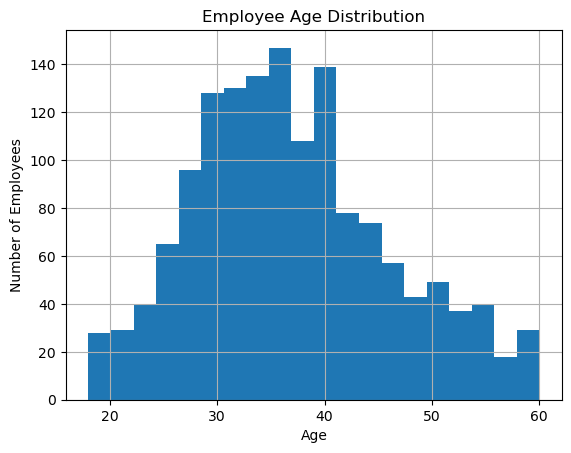

In [21]:
df["Age"].hist(bins=20)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()

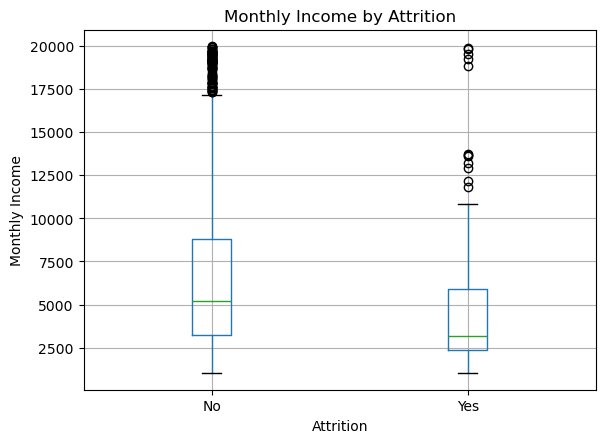

In [22]:
df.boxplot(
    column="MonthlyIncome",
    by="Attrition"
)

plt.title("Monthly Income by Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

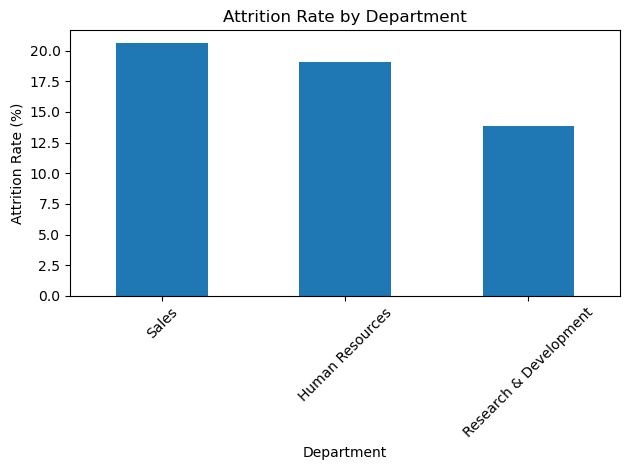

In [23]:
department_rate.plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Data cleaning and preparation

In [24]:
clean_df = df.copy()

In [25]:
# Convert column names to SQL-friendly snake_case
clean_df.columns = (
    clean_df.columns
        .str.strip()
        .str.replace(r"([a-z0-9])([A-Z])", r"\1_\2", regex=True)
        .str.lower()
)

clean_df.columns.tolist()

['age',
 'attrition',
 'business_travel',
 'daily_rate',
 'department',
 'distance_from_home',
 'education',
 'education_field',
 'employee_count',
 'employee_number',
 'environment_satisfaction',
 'gender',
 'hourly_rate',
 'job_involvement',
 'job_level',
 'job_role',
 'job_satisfaction',
 'marital_status',
 'monthly_income',
 'monthly_rate',
 'num_companies_worked',
 'over18',
 'over_time',
 'percent_salary_hike',
 'performance_rating',
 'relationship_satisfaction',
 'standard_hours',
 'stock_option_level',
 'total_working_years',
 'training_times_last_year',
 'work_life_balance',
 'years_at_company',
 'years_in_current_role',
 'years_since_last_promotion',
 'years_with_curr_manager']

In [26]:
# Remove leading/trailing spaces from text columns
text_columns = clean_df.select_dtypes(include="object").columns

for column in text_columns:
    clean_df[column] = clean_df[column].str.strip()

In [27]:
# Identify constant columns
constant_columns = [
    column
    for column in clean_df.columns
    if clean_df[column].nunique() == 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
['employee_count', 'over18', 'standard_hours']


In [28]:
clean_df = clean_df.drop(columns=constant_columns)

print(f"Columns after removing constants: {clean_df.shape[1]}")

Columns after removing constants: 32


In [29]:
clean_df = clean_df.drop_duplicates()

print(f"Rows after duplicate removal: {clean_df.shape[0]}")

Rows after duplicate removal: 1470


In [30]:
clean_df["attrition_flag"] = (
    clean_df["attrition"]
    .map({"Yes": 1, "No": 0})
)

In [31]:
clean_df[
    ["attrition", "attrition_flag"]
].value_counts()

attrition  attrition_flag
No         0                 1233
Yes        1                  237
Name: count, dtype: int64

In [34]:
print("Final Dataset Shape:")
print(clean_df.shape)

print("\nMissing Values:")
print(clean_df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(clean_df.duplicated().sum())

print("\nData Types:")
print(clean_df.dtypes)

Final Dataset Shape:
(1470, 33)

Missing Values:
0

Duplicate Rows:
0

Data Types:
age                            int64
attrition                     object
business_travel               object
daily_rate                     int64
department                    object
distance_from_home             int64
education                      int64
education_field               object
employee_number                int64
environment_satisfaction       int64
gender                        object
hourly_rate                    int64
job_involvement                int64
job_level                      int64
job_role                      object
job_satisfaction               int64
marital_status                object
monthly_income                 int64
monthly_rate                   int64
num_companies_worked           int64
over_time                     object
percent_salary_hike            int64
performance_rating             int64
relationship_satisfaction      int64
stock_option_level           